In [2]:
# =============================================================
# FRANZOSA VISUALISATIONS - PYTHON CONVERSION
# Converting Animesh's visualizations.Rmd to Python
# Data: PRISM dataset (Franzosa et al. 2019) - ST001000
# =============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# --- LOAD DATA ---
mtb = pd.read_csv('fran_met.csv', index_col=0)
metadata = pd.read_csv('fran_metadata .csv', index_col=0)

# --- CLR TRANSFORMATION ---
def clr_transform(data):
    data_plus1 = data + 1
    geometric_mean = np.exp(np.log(data_plus1).mean(axis=1))
    clr_data = np.log(data_plus1.div(geometric_mean, axis=0))
    return clr_data

tran_mtb = clr_transform(mtb)

# --- Z NORMALISATION ---
scaler = StandardScaler()
mtb_norm = pd.DataFrame(
    scaler.fit_transform(tran_mtb),
    index=tran_mtb.index,
    columns=tran_mtb.columns)

# --- REMOVE OUTLIERS ---
met_diff = mtb_norm.drop(mtb_norm.index[[125, 181]])
metadata_diff = metadata.drop(metadata.index[[125, 181]])

# --- MANN WHITNEY U TEST ---
met_diff_reset = met_diff.reset_index(drop=True)
metadata_reset = metadata_diff.reset_index(drop=True)
ibd_index = metadata_reset[metadata_reset['Disease.Group'] == 'IBD'].index
control_index = metadata_reset[metadata_reset['Disease.Group'] == 'Control'].index

p_values = []
for metabolite in met_diff_reset.columns:
    ibd_values = met_diff_reset.loc[ibd_index, metabolite]
    control_values = met_diff_reset.loc[control_index, metabolite]
    stat, p = mannwhitneyu(ibd_values, control_values, alternative='two-sided')
    p_values.append(p)

reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh', alpha=0.05)
significant = [met_diff_reset.columns[i] for i in range(len(p_adjusted)) if p_adjusted[i] < 0.05]
met_diff_sig = met_diff_reset[significant]

print("Data ready for visualisations!")
print("Final dataset shape:", met_diff_sig.shape)
print("Metadata shape:", metadata_reset.shape)

Data ready for visualisations!
Final dataset shape: (216, 897)
Metadata shape: (216, 9)


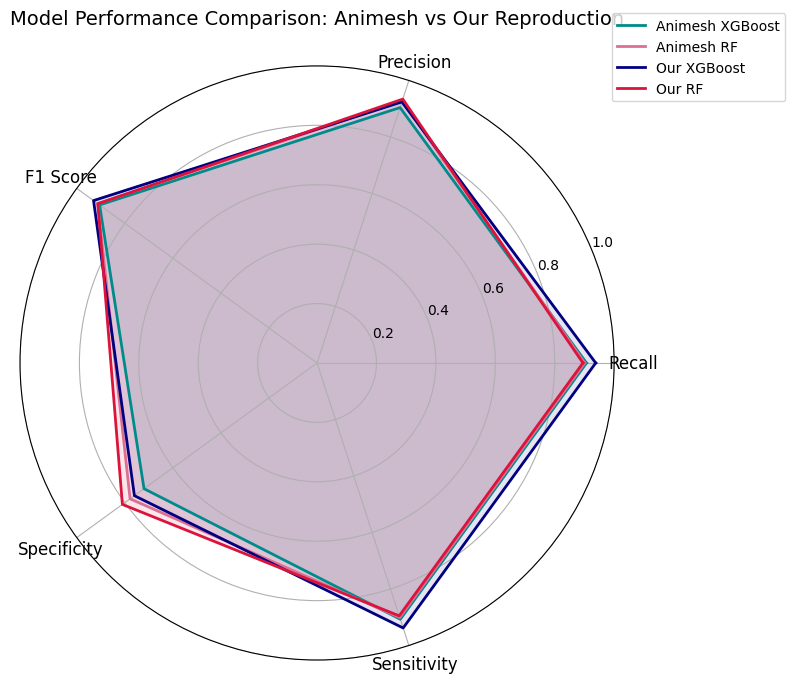

In [3]:
# =============================================================
# RADAR CHART - Model Performance Comparison
# Converting Animesh's radarchart() R code to Python
# Comparing Animesh's results vs OUR results
# =============================================================

import matplotlib.pyplot as plt
import numpy as np

# EXPLANATION:
# Radar chart plots 5 metrics on circular axes
# Each model gets its own colored shape
# Larger area = better overall performance

# Metrics: Recall, Precision, F1, Specificity, Sensitivity
categories = ['Recall', 'Precision', 'F1 Score', 'Specificity', 'Sensitivity']
N = len(categories)

# Animesh's results (hardcoded from his radar chart data)
animesh_xgb = [0.907, 0.904, 0.905, 0.720, 0.907]
animesh_rf  = [0.901, 0.928, 0.913, 0.778, 0.901]

# OUR results (from our model runs)
our_xgb = [0.938, 0.924, 0.930, 0.760, 0.938]
our_rf  = [0.895, 0.934, 0.912, 0.810, 0.895]

# Angles for each axis (evenly spaced around circle)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

# Function to close the loop for each dataset
def close_loop(data):
    return data + data[:1]

# Create the plot
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

# Plot each model
for data, label, color in zip(
    [animesh_xgb, animesh_rf, our_xgb, our_rf],
    ['Animesh XGBoost', 'Animesh RF', 'Our XGBoost', 'Our RF'],
    ['darkcyan', 'palevioletred', 'navy', 'crimson']
):
    values = close_loop(data)
    ax.plot(angles, values, color=color, linewidth=2, label=label)
    ax.fill(angles, values, color=color, alpha=0.1)

# Set category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Comparison: Animesh vs Our Reproduction', size=14, pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

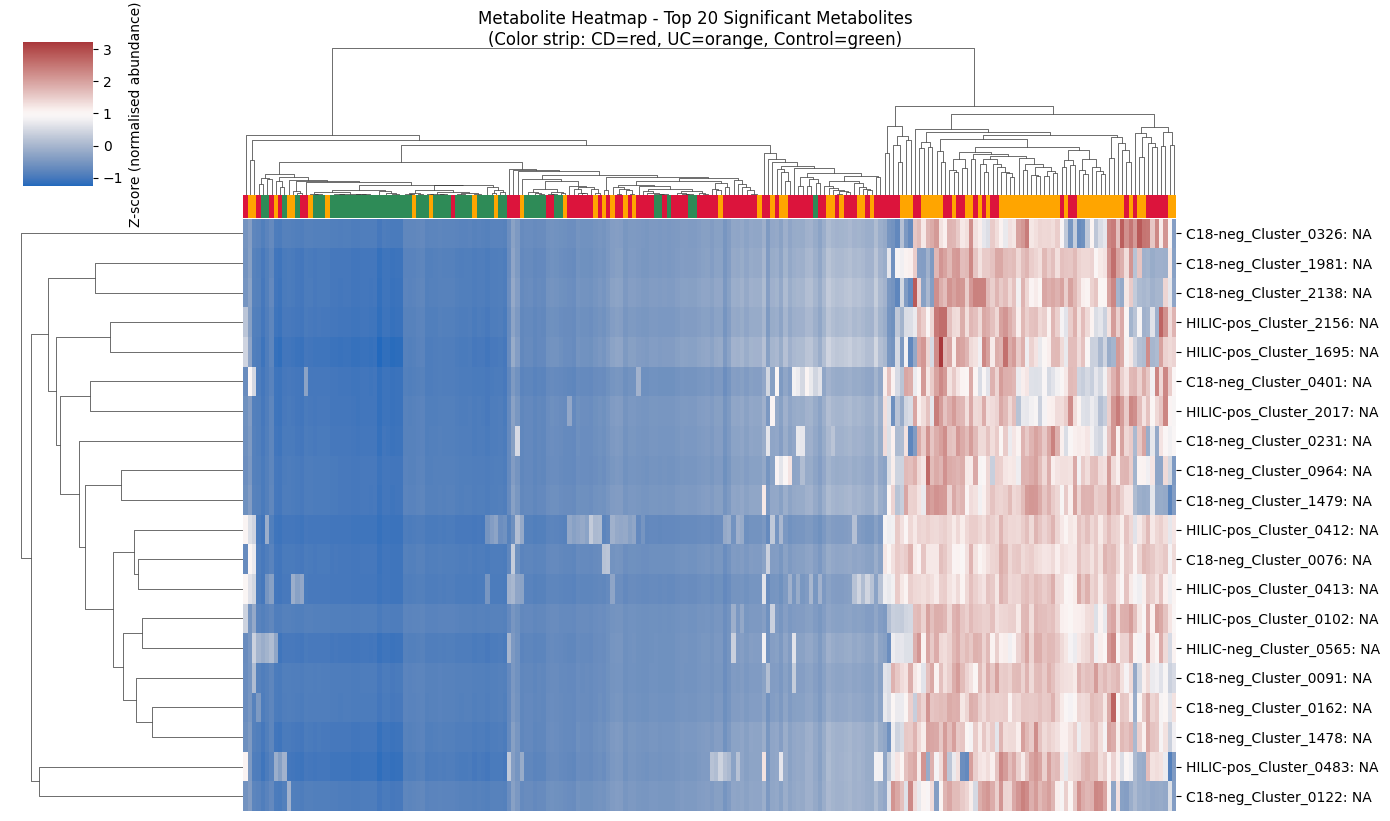

Top 20 metabolites by significance:
1. C18-neg_Cluster_0401: NA (p=0.0)
2. C18-neg_Cluster_0076: NA (p=0.0)
3. HILIC-pos_Cluster_0483: NA (p=0.0)
4. HILIC-pos_Cluster_0102: NA (p=0.0)
5. C18-neg_Cluster_0122: NA (p=0.0)
6. C18-neg_Cluster_0091: NA (p=0.0)
7. C18-neg_Cluster_0162: NA (p=0.0)
8. HILIC-pos_Cluster_2017: NA (p=0.0)
9. C18-neg_Cluster_0964: NA (p=0.0)
10. C18-neg_Cluster_1478: NA (p=0.0)
11. HILIC-pos_Cluster_2156: NA (p=0.0)
12. C18-neg_Cluster_0231: NA (p=0.0)
13. C18-neg_Cluster_1981: NA (p=0.0)
14. C18-neg_Cluster_1479: NA (p=0.0)
15. HILIC-pos_Cluster_0413: NA (p=0.0)
16. HILIC-pos_Cluster_1695: NA (p=0.0)
17. C18-neg_Cluster_2138: NA (p=0.0)
18. HILIC-neg_Cluster_0565: NA (p=0.0)
19. HILIC-pos_Cluster_0412: NA (p=0.0)
20. C18-neg_Cluster_0326: NA (p=0.0)


In [4]:
# =============================================================
# METABOLITE HEATMAP
# Converting Animesh's pheatmap() R code to Python
# Using top 20 most significant metabolites (lowest p-values)
# Annotated by Disease Group (CD/UC/Control - our 3-class extension)
# =============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# EXPLANATION:
# 1. Find the top 20 metabolites with strongest difference between groups
# 2. Create a heatmap: rows=patients, columns=metabolites, color=abundance
# 3. Add a colour strip on the side showing each patient's Disease Group

# --- Step 1: Find top 20 most significant metabolites ---
# Using met_diff_sig (897 metabolites) and metadata_reset (216 patients)
p_vals_heat = []
for col in met_diff_sig.columns:
    ibd_vals = met_diff_sig.loc[ibd_index, col]
    con_vals = met_diff_sig.loc[control_index, col]
    _, p = mannwhitneyu(ibd_vals, con_vals)
    p_vals_heat.append(p)

p_series = pd.Series(p_vals_heat, index=met_diff_sig.columns)
top20 = p_series.sort_values().head(20).index

heatmap_data = met_diff_sig[top20]

# --- Step 2: Create colour annotation for Disease Group (3-class) ---
disease_groups = metadata_reset['Study.Group']  # CD, UC, Control
color_map = {'CD': 'crimson', 'UC': 'orange', 'Control': 'seagreen'}
row_colors = disease_groups.map(color_map)

# --- Step 3: Plot heatmap ---
g = sns.clustermap(
    heatmap_data.T,                # transpose: metabolites as rows, patients as columns
    cmap='vlag',                   # blue-white-red colormap (similar to pheatmap default)
    col_colors=row_colors.values,
    figsize=(14, 8),
    xticklabels=False,             # too many patients to label individually
    yticklabels=True,
    cbar_kws={'label': 'Z-score (normalised abundance)'}
)

g.fig.suptitle('Metabolite Heatmap - Top 20 Significant Metabolites\n(Color strip: CD=red, UC=orange, Control=green)', y=1.02)
plt.show()

print("Top 20 metabolites by significance:")
for i, met in enumerate(top20, 1):
    print(f"{i}. {met} (p={round(p_series[met],6)})")